
# 00_preprocess_raw_data

Ten notebook przygotowuje plik pomiarowy do dalszego modelowania powierzchni 2D P-splines.

Przepływ danych:

```text
data/raw/A-B_VI_sample02.csv
    -> data/processed/A-B_VI_voltage_cleared_sample02.csv
```

Celem notebooka jest:

1. wczytanie surowego pliku CSV w formacie macierzy pomiarowej,
2. konwersja danych do postaci długiej z kolumnami `I`, `T`, `Uraw`,
3. znalezienie napięciowego punktu cut-off,
4. usunięcie punktów leżących dokładnie na tym cut-offie,
5. zapis oczyszczonych danych do katalogu `data/processed`.

Plik wynikowy jest wejściem do notebooka P-splines, w którym przyjmujemy:

```text
x = I
y = T
observed_z = Uraw
```

Notebook nie dopasowuje jeszcze modelu P-splines. Jego zadaniem jest wyłącznie przygotowanie danych pomiarowych.



## 1. Import bibliotek

Używane są standardowe biblioteki do:

- obsługi ścieżek (`pathlib`),
- czytania CSV (`csv`, `pandas`),
- obliczeń numerycznych (`numpy`),
- wykresów diagnostycznych (`matplotlib`),
- opcjonalnego wygładzenia diagnostycznego i obliczenia pochodnej `dU/dI` (`scipy.signal.savgol_filter`).

Kolumny diagnostyczne `Usmooth`, `Rd` i `dRd_dI` **nie są zapisywane** do pliku processed. Służą jedynie do oceny jakości danych po oczyszczeniu.


In [1]:

from __future__ import annotations

from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter



## 2. Konfiguracja ścieżek

Notebook zakłada następującą strukturę repozytorium:

```text
project_root/
  data/
    raw/
      A-B_VI_sample02.csv
    processed/
      A-B_VI_voltage_cleared_sample02.csv
  notebooks/
    00_preprocess_raw_data.ipynb
```

Funkcja `find_project_root(...)` pozwala uruchamiać notebook zarówno z katalogu głównego projektu, jak i bezpośrednio z katalogu `notebooks`.

Parametr `SAMPLE` określa numer próbki. Dla:

```python
SAMPLE = "02"
```

notebook czyta:

```text
data/raw/A-B_VI_sample02.csv
```

i zapisuje:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```


In [2]:

SAMPLE = "02"

# W surowym pliku pierwszy wiersz zawiera temperatury T,
# pierwsza kolumna zawiera prąd źródła I,
# a wnętrze macierzy zawiera zmierzone napięcie Uraw.
SOURCE_IS_CURRENT = True

RAW_FILE_NAME = f"A-B_VI_sample{SAMPLE}.csv"
OUTPUT_FILE_NAME = f"A-B_VI_voltage_cleared_sample{SAMPLE}.csv"

# Opcjonalny ręczny limit napięcia.
# Jeżeli pozostaje None, limit jest wyznaczany automatycznie jako max(abs(Uraw)).
MANUAL_VOLTAGE_LIMIT: float | None = None


def find_project_root(start: Path | None = None) -> Path:
    """Return project root containing both `data/` and `notebooks/`.

    This keeps the notebook portable between:
    - running from the repository root;
    - running from the `notebooks/` directory in PyCharm/Jupyter.
    """
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    if start.name.lower() == "notebooks":
        return start.parent

    return start


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CSV_PATH = RAW_DIR / RAW_FILE_NAME
OUTPUT_CSV_PATH = PROCESSED_DIR / OUTPUT_FILE_NAME

print(f"PROJECT_ROOT:        {PROJECT_ROOT}")
print(f"RAW_DIR:             {RAW_DIR}")
print(f"PROCESSED_DIR:       {PROCESSED_DIR}")
print(f"Plik wejściowy:      {SAMPLE_CSV_PATH}")
print(f"Plik wynikowy:       {OUTPUT_CSV_PATH}")
print(f"MANUAL_VOLTAGE_LIMIT: {MANUAL_VOLTAGE_LIMIT}")


PROJECT_ROOT:        D:\PycharmProjects\2D_p-splines-fiiting
RAW_DIR:             D:\PycharmProjects\2D_p-splines-fiiting\data\raw
PROCESSED_DIR:       D:\PycharmProjects\2D_p-splines-fiiting\data\processed
Plik wejściowy:      D:\PycharmProjects\2D_p-splines-fiiting\data\raw\A-B_VI_sample02.csv
Plik wynikowy:       D:\PycharmProjects\2D_p-splines-fiiting\data\processed\A-B_VI_voltage_cleared_sample02.csv
MANUAL_VOLTAGE_LIMIT: None



## 3. Format surowego pliku CSV

Surowy plik `A-B_VI_sample02.csv` ma postać macierzy:

- komórka `[0,0]` jest techniczna i nie jest używana jako pomiar;
- pierwszy wiersz od drugiej kolumny zawiera wartości temperatury \(T\);
- pierwsza kolumna od drugiego wiersza zawiera wartości prądu \(I\);
- wnętrze macierzy zawiera zmierzone napięcie \(U_{\mathrm{raw}}\).

Schemat:

```text
          T1       T2       T3      ...
I1      U11      U12      U13      ...
I2      U21      U22      U23      ...
I3      U31      U32      U33      ...
...
```

Notebook przekształca tę macierz do postaci długiej:

```text
I, T, Uraw
```

czyli każdy punkt pomiarowy staje się jednym wierszem DataFrame.


In [3]:

def read_csv_any_delimiter(path: Path) -> list[list[str]]:
    """Read CSV that may be separated by semicolon or comma."""
    for delimiter in (";", ","):
        with path.open(newline="", encoding="utf-8") as file:
            rows = [row for row in csv.reader(file, delimiter=delimiter) if row]

        if rows and len(rows[0]) > 1:
            return rows

    raise ValueError(f"Could not determine CSV delimiter for file: {path}")


def build_raw_dataframe(
    path_to_csv_data: Path | str,
    *,
    source_is_current: bool = True,
) -> pd.DataFrame:
    """Convert raw matrix-like CSV into long-form DataFrame.

    Parameters
    ----------
    path_to_csv_data:
        Path to raw CSV file.
    source_is_current:
        If True, the first column is interpreted as current `I`.
        If False, the first column is interpreted as voltage and the matrix values as current.
        For `A-B_VI_sample02.csv` use True.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns `I`, `T`, `Uraw`.
    """
    rows = read_csv_any_delimiter(Path(path_to_csv_data))

    if len(rows) < 2 or len(rows[0]) < 2:
        raise ValueError("CSV does not look like a matrix with header row and first column.")

    temperatures = [float(value) for value in rows[0][1:]]

    first_column: list[float] = []
    matrix: list[list[float]] = []

    expected_width = len(rows[0])
    for row_number, row in enumerate(rows[1:], start=2):
        if len(row) != expected_width:
            raise ValueError(
                f"Row {row_number} has width {len(row)}, expected {expected_width}."
            )

        first_column.append(float(row[0]))
        matrix.append([float(value) for value in row[1:]])

    triplets: list[tuple[float, float, float]] = []

    if source_is_current:
        for row_index, current in enumerate(first_column):
            for col_index, temperature in enumerate(temperatures):
                voltage = matrix[row_index][col_index]
                triplets.append((current, temperature, voltage))
    else:
        for row_index, voltage in enumerate(first_column):
            for col_index, temperature in enumerate(temperatures):
                current = matrix[row_index][col_index]
                triplets.append((current, temperature, voltage))

    return pd.DataFrame(triplets, columns=["I", "T", "Uraw"])



## 4. Wczytanie i kontrola danych surowych

Po konwersji sprawdzamy:

- liczbę wierszy,
- liczbę unikalnych wartości `I` i `T`,
- zakres napięcia `Uraw`,
- obecność wartości `NaN` lub `inf`.

Dla `sample02` oczekiwany rozmiar przed filtrowaniem to:

\[
101 \times 62 = 6262
\]

punktów pomiarowych.


In [4]:

if not SAMPLE_CSV_PATH.exists():
    raise FileNotFoundError(f"Nie znaleziono pliku: {SAMPLE_CSV_PATH}")

raw_df = build_raw_dataframe(SAMPLE_CSV_PATH, source_is_current=SOURCE_IS_CURRENT)

required_columns = ["I", "T", "Uraw"]
missing_columns = set(required_columns).difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {sorted(missing_columns)}")

if not np.all(np.isfinite(raw_df[required_columns].to_numpy(dtype=float))):
    raise ValueError("Dane surowe po konwersji zawierają NaN lub inf.")

print("=== raw_df.head() ===")
display(raw_df.head())

print("\n=== raw_df.info() ===")
raw_df.info()

print("\n=== raw_df.describe() ===")
display(raw_df.describe())

print("\n=== Liczność siatki ===")
print(f"liczba wierszy:       {len(raw_df)}")
print(f"unikalne wartości I:  {raw_df['I'].nunique()}")
print(f"unikalne wartości T:  {raw_df['T'].nunique()}")
print(f"spodziewane punkty:   {raw_df['I'].nunique() * raw_df['T'].nunique()}")


=== raw_df.head() ===


,I,T,Uraw
0,0.005,315.107,0.283050
1,0.005,309.999,0.305602
2,0.005,304.986,0.311983
3,0.005,299.945,0.321344
4,0.005,294.984,0.334987



=== raw_df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 6262 entries, 0 to 6261
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I       6262 non-null   float64
 1   T       6262 non-null   float64
 2   Uraw    6262 non-null   float64
dtypes: float64(3)
memory usage: 146.9 KB

=== raw_df.describe() ===


,I,T,Uraw
count,6262.000000,6262.000000,6262.000000
mean,0.000000,162.442078,-0.000193
std,0.002916,89.504066,0.284405
min,-0.005000,9.678340,-0.832711
25%,-0.002500,84.961800,-0.210277
50%,0.000000,162.469500,-0.000155
75%,0.002500,239.973000,0.209927
max,0.005000,315.107000,0.832501



=== Liczność siatki ===
liczba wierszy:       6262
unikalne wartości I:  101
unikalne wartości T:  62
spodziewane punkty:   6262



## 5. Diagnostyczny wykres powierzchni `Uraw(T,I)` przed filtrowaniem

Wykres pozwala zobaczyć, czy w danych występują punkty leżące na ograniczeniu napięciowym aparatury.

Na tym etapie niczego jeszcze nie usuwamy.


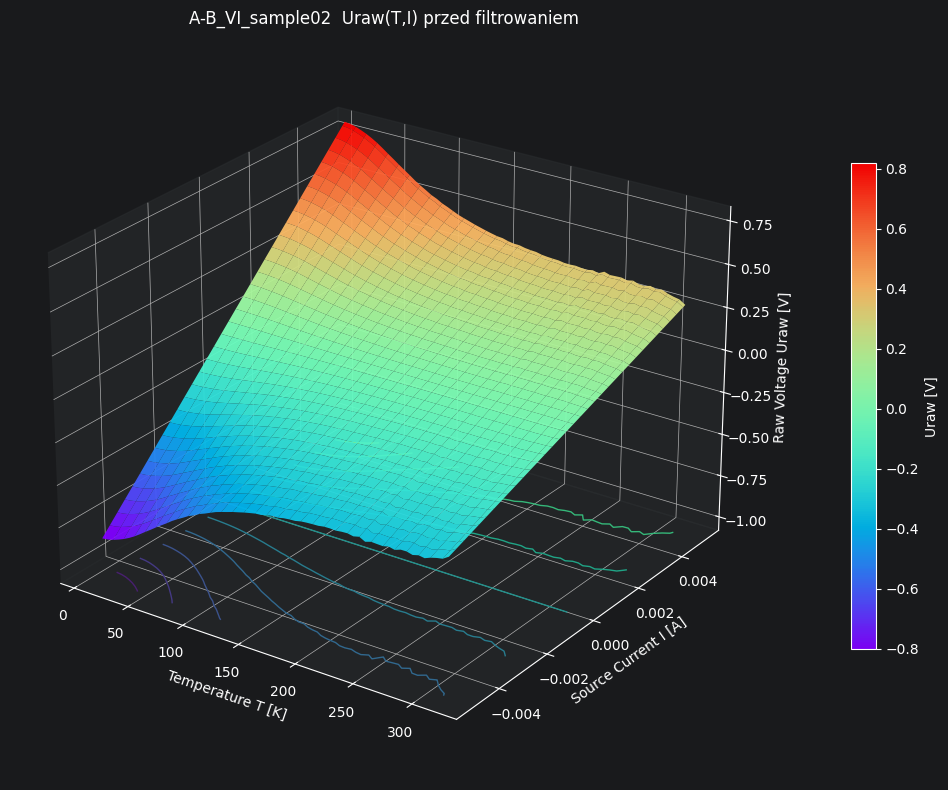

In [5]:

plot_df = raw_df.loc[:, ["I", "T", "Uraw"]].dropna(subset=["I", "T", "Uraw"]).copy()

pivot = (
    plot_df.pivot_table(index="T", columns="I", values="Uraw", aggfunc="mean")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

if pivot.empty:
    raise ValueError("Brak danych do narysowania wykresu.")

t_values = pivot.index.to_numpy(dtype=float)
i_values = pivot.columns.to_numpy(dtype=float)
u_matrix = pivot.to_numpy(dtype=float)

ii, tt = np.meshgrid(i_values, t_values)
u_masked = np.ma.masked_invalid(u_matrix)

finite_values = u_matrix[np.isfinite(u_matrix)]
z_min = float(np.nanmin(finite_values))
z_max = float(np.nanmax(finite_values))
z_offset = z_min - 0.15 * (z_max - z_min if z_max > z_min else 1.0)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    tt,
    ii,
    u_masked,
    cmap="rainbow",
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)

try:
    ax.contour(
        tt,
        ii,
        u_masked,
        zdir="z",
        offset=z_offset,
        levels=12,
        cmap="viridis",
        linewidths=1.0,
    )
except Exception:
    pass

colorbar = fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.08)
colorbar.set_label("Uraw [V]")

ax.set_title(f"{SAMPLE_CSV_PATH.stem}  Uraw(T,I) przed filtrowaniem")
ax.set_xlabel("Temperature T [K]")
ax.set_ylabel("Source Current I [A]")
ax.set_zlabel("Raw Voltage Uraw [V]")

ax.set_zlim(z_offset, z_max)
ax.view_init(elev=25, azim=-55)
ax.grid(True)

plt.tight_layout()
plt.show()



## 6. Wyznaczenie napięcia cut-off

W tym notebooku napięciowy cut-off jest rozpoznawany jako maksymalna wartość bezwzględna zmierzonego napięcia:

\[
U_{\mathrm{limit}}
=
\max_i |U_{\mathrm{raw},i}|.
\]

Dla danych `sample02` punkt cut-off występuje dokładnie na krańcu zakresu pomiarowego. Chcemy usunąć punkty, które spełniają:

\[
|U_{\mathrm{raw},i}| = U_{\mathrm{limit}}.
\]

Technicznie filtr zapisujemy jako ostrą nierówność:

\[
-U_{\mathrm{limit}} < U_{\mathrm{raw},i} < U_{\mathrm{limit}}.
\]

Ostra nierówność usuwa punkty dokładnie na granicy cut-offu, ale zostawia punkty położone wewnątrz zakresu pomiarowego.

Jeżeli znasz limit aparatury z dokumentacji, możesz ustawić `MANUAL_VOLTAGE_LIMIT`. W przeciwnym razie notebook używa limitu automatycznego.


In [6]:

u_min = float(raw_df["Uraw"].min())
u_max = float(raw_df["Uraw"].max())
auto_voltage_limit = float(raw_df["Uraw"].abs().max())

VOLTAGE_LIMIT = auto_voltage_limit if MANUAL_VOLTAGE_LIMIT is None else float(MANUAL_VOLTAGE_LIMIT)

cutoff_mask = raw_df["Uraw"].le(-VOLTAGE_LIMIT) | raw_df["Uraw"].ge(VOLTAGE_LIMIT)
cutoff_points = raw_df.loc[cutoff_mask, ["I", "T", "Uraw"]].copy()

print(f"Uraw min = {u_min:.9g} V")
print(f"Uraw max = {u_max:.9g} V")
print(f"auto_voltage_limit = {auto_voltage_limit:.9g} V")
print(f"VOLTAGE_LIMIT used = {VOLTAGE_LIMIT:.9g} V")
print(f"Liczba punktów na cut-offie: {len(cutoff_points)}")

if len(cutoff_points) > 0:
    print("\n=== Punkty cut-off ===")
    display(cutoff_points)


Uraw min = -0.832711 V
Uraw max = 0.832501 V
auto_voltage_limit = 0.832711 V
VOLTAGE_LIMIT used = 0.832711 V
Liczba punktów na cut-offie: 1

=== Punkty cut-off ===


,I,T,Uraw
6261,-0.005,9.67834,-0.832711



## 7. Usunięcie punktów cut-off

Tworzymy `processed_df`, który zawiera wyłącznie kolumny potrzebne w dalszym modelowaniu:

```text
I, T, Uraw
```

Nie zapisujemy do pliku processed kolumn diagnostycznych. Dzięki temu plik wynikowy pozostaje prosty i jest bezpośrednio zgodny z notebookiem P-splines:

```text
x = I
y = T
target_z = Uraw
```


In [7]:

rows_before = len(raw_df)

processed_df = (
    raw_df.loc[raw_df["Uraw"].gt(-VOLTAGE_LIMIT) & raw_df["Uraw"].lt(VOLTAGE_LIMIT), ["I", "T", "Uraw"]]
    .copy()
    .reset_index(drop=True)
)

rows_after = len(processed_df)
rows_removed = rows_before - rows_after

if rows_after == 0:
    raise ValueError("Filtr cut-off usunął wszystkie dane. Sprawdź VOLTAGE_LIMIT.")

if not np.all(np.isfinite(processed_df[["I", "T", "Uraw"]].to_numpy(dtype=float))):
    raise ValueError("processed_df zawiera NaN lub inf.")

print(f"VOLTAGE_LIMIT = {VOLTAGE_LIMIT:.9g} V")
print(f"Liczba wierszy przed filtrem: {rows_before}")
print(f"Liczba wierszy po filtrze:   {rows_after}")
print(f"Usunięto wierszy:            {rows_removed}")

print("\n=== processed_df.head() ===")
display(processed_df.head())

print("\n=== processed_df.describe() ===")
display(processed_df.describe())


VOLTAGE_LIMIT = 0.832711 V
Liczba wierszy przed filtrem: 6262
Liczba wierszy po filtrze:   6261
Usunięto wierszy:            1

=== processed_df.head() ===


,I,T,Uraw
0,0.005,315.107,0.283050
1,0.005,309.999,0.305602
2,0.005,304.986,0.311983
3,0.005,299.945,0.321344
4,0.005,294.984,0.334987



=== processed_df.describe() ===


,I,T,Uraw
count,6.261000e+03,6261.000000,6261.000000
mean,7.985945e-07,162.466477,-0.000060
std,2.915257e-03,89.490385,0.284233
min,-5.000000e-03,9.678340,-0.828134
25%,-2.500000e-03,84.961800,-0.210239
50%,0.000000e+00,164.957000,-0.000155
75%,2.500000e-03,239.973000,0.209969
max,5.000000e-03,315.107000,0.832501



## 8. Zapis pliku processed

Zapisujemy oczyszczone dane do:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

Plik ten jest deterministycznym wynikiem działania notebooka dla danego pliku surowego i ustawionego limitu napięcia.


In [8]:

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_df.to_csv(OUTPUT_CSV_PATH, index=False)

print("Zapisano oczyszczone dane po voltage cutoff:")
print(OUTPUT_CSV_PATH)

print("\n=== Informacje o zapisie ===")
print(f"Plik źródłowy:              {SAMPLE_CSV_PATH}")
print(f"Plik wynikowy:              {OUTPUT_CSV_PATH}")
print(f"SAMPLE:                    {SAMPLE}")
print(f"VOLTAGE_LIMIT:             {VOLTAGE_LIMIT:.9g}")
print(f"Liczba zapisanych wierszy: {len(processed_df)}")
print(f"Kolumny:                   {list(processed_df.columns)}")

print("\n=== Bilans voltage cutoff ===")
print(f"Liczba wierszy przed filtrem: {rows_before}")
print(f"Liczba wierszy po filtrze:   {rows_after}")
print(f"Usunięto wierszy:            {rows_removed}")


Zapisano oczyszczone dane po voltage cutoff:
D:\PycharmProjects\2D_p-splines-fiiting\data\processed\A-B_VI_voltage_cleared_sample02.csv

=== Informacje o zapisie ===
Plik źródłowy:              D:\PycharmProjects\2D_p-splines-fiiting\data\raw\A-B_VI_sample02.csv
Plik wynikowy:              D:\PycharmProjects\2D_p-splines-fiiting\data\processed\A-B_VI_voltage_cleared_sample02.csv
SAMPLE:                    02
VOLTAGE_LIMIT:             0.832711
Liczba zapisanych wierszy: 6261
Kolumny:                   ['I', 'T', 'Uraw']

=== Bilans voltage cutoff ===
Liczba wierszy przed filtrem: 6262
Liczba wierszy po filtrze:   6261
Usunięto wierszy:            1



## 9. Kontrola zapisanego pliku

Po zapisie ponownie wczytujemy CSV z katalogu `data/processed` i sprawdzamy:

- czy plik istnieje,
- czy ma dokładnie kolumny `I`, `T`, `Uraw`,
- czy nie zawiera `NaN` ani `inf`,
- czy nie zawiera punktów leżących na cut-offie,
- czy zapisany plik jest identyczny z `processed_df`.


In [9]:

if not OUTPUT_CSV_PATH.exists():
    raise FileNotFoundError(f"Nie zapisano pliku: {OUTPUT_CSV_PATH}")

saved_df = pd.read_csv(OUTPUT_CSV_PATH)

expected_columns = ["I", "T", "Uraw"]
if list(saved_df.columns) != expected_columns:
    raise AssertionError(
        f"Nieprawidłowe kolumny w pliku processed: {list(saved_df.columns)}, "
        f"oczekiwano: {expected_columns}"
    )

if not np.all(np.isfinite(saved_df[expected_columns].to_numpy(dtype=float))):
    raise AssertionError("Zapisany plik zawiera NaN lub inf.")

if ((saved_df["Uraw"] <= -VOLTAGE_LIMIT) | (saved_df["Uraw"] >= VOLTAGE_LIMIT)).any():
    raise AssertionError("Zapisany plik nadal zawiera punkty na cut-offie.")

pd.testing.assert_frame_equal(saved_df, processed_df, check_dtype=False)

print("OK: zapisany plik processed jest poprawny.")
print(f"shape: {saved_df.shape}")
print(f"Uraw min: {saved_df['Uraw'].min():.9g}")
print(f"Uraw max: {saved_df['Uraw'].max():.9g}")
print(f"unikalne I: {saved_df['I'].nunique()}")
print(f"unikalne T: {saved_df['T'].nunique()}")


OK: zapisany plik processed jest poprawny.
shape: (6261, 3)
Uraw min: -0.828134
Uraw max: 0.832501
unikalne I: 101
unikalne T: 62


## 10. Diagnostyka pomocnicza: wygładzenie i rezystancja dynamiczna

Ta sekcja ma charakter **wyłącznie diagnostyczny**. Nie zmienia pliku wynikowego `data/processed/A-B_VI_voltage_cleared_sample02.csv` i nie dodaje do niego nowych kolumn.

Celem tej części jest sprawdzenie, czy po usunięciu punktów napięciowego cut-offu przebiegi napięciowo-prądowe mają fizycznie sensowny kształt. W szczególności oglądamy lokalną rezystancję dynamiczną, czyli nachylenie krzywej napięcia względem prądu.

Dane po oczyszczeniu mają postać punktów:

$$
(I_i, T_i, U_{\mathrm{raw},i}).
$$

Dla każdej ustalonej temperatury $T=T_k$ rozpatrujemy osobny przekrój pomiarowy:

$$
U_{\mathrm{raw}} = U_{\mathrm{raw}}(I \mid T_k).
$$

W praktyce oznacza to, że kod wykonuje operację `groupby("T")`, a następnie dla każdej grupy sortuje punkty według prądu `I`. Dzięki temu filtr i pochodne są liczone wzdłuż osi prądu, a nie po przypadkowej kolejności wierszy w pliku CSV.

### Wygładzenie Savitzky’ego-Golaya

Dla każdego przekroju temperaturowego stosowany jest filtr Savitzky’ego-Golaya. Lokalnie dopasowuje on wielomian niskiego stopnia do małego okna punktów pomiarowych. W tym notebooku domyślnie używane są parametry:

```python
window_length = 11
polyorder = 2
```

Jeżeli w danym przekroju temperaturowym jest mniej punktów niż domyślna długość okna, kod automatycznie zmniejsza okno do największej możliwej nieparzystej wartości. Jest to konieczne, ponieważ filtr Savitzky’ego-Golaya wymaga nieparzystej długości okna i liczby punktów większej od stopnia wielomianu.

Wygładzony sygnał oznaczamy jako:

$$
U_{\mathrm{smooth}}(I,T)
\approx
U_{\mathrm{raw}}(I,T).
$$

Kolumna `Usmooth` jest więc lokalnie wygładzoną wersją kolumny `Uraw`. Nie jest używana jako dane wejściowe do kolejnego etapu pipeline’u.

### Krok prądowy używany do pochodnych

Pochodne są liczone względem prądu $I$. Dla każdego przekroju temperaturowego kod wyznacza typowy krok prądowy jako medianę dodatnich różnic między kolejnymi wartościami prądu:

$$
\Delta I
=
\operatorname{median}\{I_{j+1}-I_j : I_{j+1}>I_j\}.
$$

Ta wartość jest przekazywana do filtru Savitzky’ego-Golaya przez argument `delta`. Dzięki temu pochodne mają prawidłowe jednostki fizyczne.

### Rezystancja dynamiczna

Rezystancja dynamiczna jest definiowana jako pochodna napięcia po prądzie:

$$
R_d(I,T)
=
\frac{\partial U(I,T)}{\partial I}.
$$

W kodzie odpowiada jej kolumna `Rd`, wyznaczana przez filtr Savitzky’ego-Golaya z argumentem:

```python
deriv = 1
```

Jednostką tej wielkości jest om, ponieważ:

$$
\frac{\mathrm{V}}{\mathrm{A}}
=
\Omega.
$$

Wartości `Rd` pomagają wykryć niefizyczne skoki, niestabilności numeryczne albo pozostałości po punktach cut-offu.

### Pochodna rezystancji dynamicznej

Dodatkowo wyznaczana jest pochodna rezystancji dynamicznej po prądzie:

$$
\frac{\partial R_d(I,T)}{\partial I}
=
\frac{\partial^2 U(I,T)}{\partial I^2}.
$$

W kodzie odpowiada jej kolumna `dRd_dI`, wyznaczana przez filtr Savitzky’ego-Golaya z argumentem:

```python
deriv = 2
```

Ta wielkość jest bardziej wrażliwa na szum niż `Rd`, dlatego traktujemy ją tylko jako pomocniczą diagnostykę krzywizny przebiegu $U(I \mid T)$.

### Zakres wpływu tej sekcji

Ta sekcja tworzy roboczy DataFrame `diagnostic_df`, który zawiera kolumny:

```text
I, T, Uraw, Usmooth, Rd, dRd_dI
```

Natomiast plik processed zapisywany w tym notebooku pozostaje minimalny i zawiera wyłącznie:

```text
I, T, Uraw
```

Kolumny `Usmooth`, `Rd` i `dRd_dI` służą tylko do wykresów kontrolnych oraz do oceny jakości oczyszczenia danych. Nie są zapisywane do `data/processed/A-B_VI_voltage_cleared_sample02.csv`, ponieważ kolejny notebook 2D P-splines powinien otrzymać nieprzekształcone wartości pomiarowe `Uraw` po usunięciu punktów cut-offu.


In [10]:

def _odd_window_at_most(n: int, preferred: int, minimum: int = 3) -> int:
    if n <= 0:
        return 0

    window = min(preferred, n)
    if window % 2 == 0:
        window -= 1

    if window < minimum:
        candidate = n if n % 2 == 1 else n - 1
        window = max(1, candidate)

    return window


def _median_positive_step(x: np.ndarray) -> float:
    diffs = np.diff(x)
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if diffs.size == 0:
        return np.nan
    return float(np.median(diffs))


def add_usmooth_rd(
    df: pd.DataFrame,
    *,
    value_column: str = "Uraw",
    current_column: str = "I",
    temperature_column: str = "T",
    smooth_column: str = "Usmooth",
    rd_column: str = "Rd",
    drd_di_column: str = "dRd_dI",
    window_length: int = 11,
    polyorder: int = 2,
) -> pd.DataFrame:
    """Add diagnostic smoothed voltage and numerical derivatives by temperature."""
    required_columns = {value_column, current_column, temperature_column}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Brakuje kolumn: {', '.join(sorted(missing_columns))}")

    parts: list[pd.DataFrame] = []

    for _, group in df.groupby(temperature_column, sort=True):
        g = group.sort_values(current_column).copy()

        x_all = pd.to_numeric(g[current_column], errors="coerce").to_numpy(dtype=float)
        y_all = pd.to_numeric(g[value_column], errors="coerce").to_numpy(dtype=float)

        usmooth_all = np.full(len(g), np.nan, dtype=float)
        rd_all = np.full(len(g), np.nan, dtype=float)
        drd_di_all = np.full(len(g), np.nan, dtype=float)

        valid_x_mask = np.isfinite(x_all)
        if valid_x_mask.any():
            work = pd.DataFrame(
                {
                    "x": x_all[valid_x_mask],
                    "y": y_all[valid_x_mask],
                }
            )

            work["y_interp"] = work["y"].interpolate(method="linear", limit_area="inside")

            x_work = work["x"].to_numpy(dtype=float)
            y_work = work["y_interp"].to_numpy(dtype=float)
            valid_y_mask = np.isfinite(y_work)

            usmooth_work = np.full(len(work), np.nan, dtype=float)
            rd_work = np.full(len(work), np.nan, dtype=float)
            drd_di_work = np.full(len(work), np.nan, dtype=float)

            if valid_y_mask.sum() >= 3:
                idx = np.flatnonzero(valid_y_mask)
                start = int(idx[0])
                stop = int(idx[-1]) + 1

                x_core = x_work[start:stop]
                y_core = y_work[start:stop]
                n_core = len(y_core)

                effective_window = _odd_window_at_most(n_core, window_length, minimum=3)
                effective_polyorder = min(polyorder, effective_window - 1)
                delta = _median_positive_step(x_core)

                if (
                    effective_window >= 3
                    and effective_polyorder >= 1
                    and n_core >= effective_window
                    and np.isfinite(delta)
                    and delta > 0
                ):
                    usmooth_core = savgol_filter(
                        y_core,
                        window_length=effective_window,
                        polyorder=effective_polyorder,
                        deriv=0,
                        delta=delta,
                        mode="interp",
                    )

                    rd_core = savgol_filter(
                        y_core,
                        window_length=effective_window,
                        polyorder=effective_polyorder,
                        deriv=1,
                        delta=delta,
                        mode="interp",
                    )

                    if effective_polyorder >= 2:
                        drd_di_core = savgol_filter(
                            y_core,
                            window_length=effective_window,
                            polyorder=effective_polyorder,
                            deriv=2,
                            delta=delta,
                            mode="interp",
                        )
                    else:
                        drd_di_core = np.full(n_core, np.nan, dtype=float)
                else:
                    usmooth_core = y_core.copy()
                    rd_core = np.full(n_core, np.nan, dtype=float)
                    drd_di_core = np.full(n_core, np.nan, dtype=float)

                usmooth_work[start:stop] = usmooth_core
                rd_work[start:stop] = rd_core
                drd_di_work[start:stop] = drd_di_core

            usmooth_all[valid_x_mask] = usmooth_work
            rd_all[valid_x_mask] = rd_work
            drd_di_all[valid_x_mask] = drd_di_work

        g[smooth_column] = usmooth_all
        g[rd_column] = rd_all
        g[drd_di_column] = drd_di_all
        parts.append(g)

    return pd.concat(parts).sort_index()


diagnostic_df = add_usmooth_rd(
    processed_df,
    value_column="Uraw",
    current_column="I",
    temperature_column="T",
    smooth_column="Usmooth",
    rd_column="Rd",
    drd_di_column="dRd_dI",
    window_length=11,
    polyorder=2,
)

print(diagnostic_df[["I", "T", "Uraw", "Usmooth", "Rd", "dRd_dI"]].head())


       I        T      Uraw   Usmooth         Rd      dRd_dI
0  0.005  315.107  0.283050  0.283050  56.684471   34.032634
1  0.005  309.999  0.305602  0.305600  61.278876  113.752914
2  0.005  304.986  0.311983  0.311981  62.519758   78.787879
3  0.005  299.945  0.321344  0.321341  64.477550  169.463869
4  0.005  294.984  0.334987  0.334982  67.339021  267.132867



## 11. Wykres diagnostyczny `Rd(T,I)`

Wykres `Rd(T,I)` pokazuje, jak zmienia się lokalna rezystancja dynamiczna po oczyszczeniu danych. Jest to tylko kontrola jakości przebiegu po filtracji cut-offu.

Plik processed nadal zawiera wyłącznie:

```text
I, T, Uraw
```


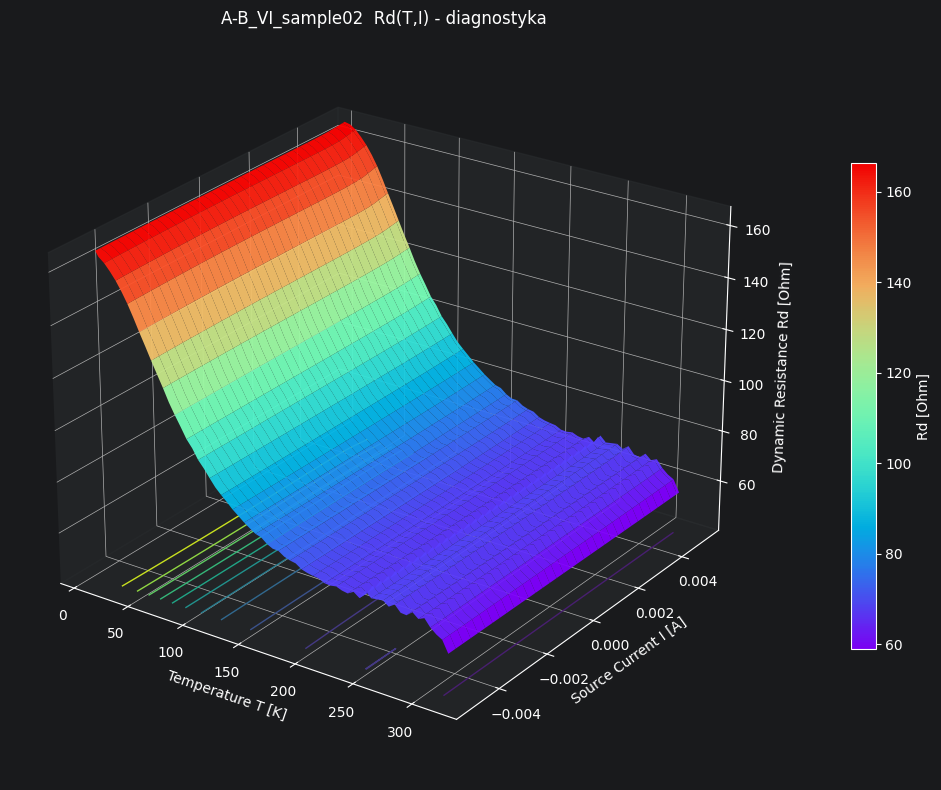

In [11]:

required_columns = {"I", "T", "Rd"}
missing_columns = required_columns.difference(diagnostic_df.columns)
if missing_columns:
    raise ValueError(f"Brakuje kolumn w diagnostic_df: {', '.join(sorted(missing_columns))}")

plot_df = diagnostic_df.loc[:, ["I", "T", "Rd"]].dropna(subset=["I", "T", "Rd"]).copy()

pivot = (
    plot_df.pivot_table(index="T", columns="I", values="Rd", aggfunc="mean")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

if pivot.empty:
    raise ValueError("Brak danych do narysowania wykresu Rd(T,I).")

t_values = pivot.index.to_numpy(dtype=float)
i_values = pivot.columns.to_numpy(dtype=float)
rd_matrix = pivot.to_numpy(dtype=float)

ii, tt = np.meshgrid(i_values, t_values)
rd_masked = np.ma.masked_invalid(rd_matrix)

finite_values = rd_matrix[np.isfinite(rd_matrix)]
z_min = float(np.nanmin(finite_values))
z_max = float(np.nanmax(finite_values))
z_offset = z_min - 0.15 * (z_max - z_min if z_max > z_min else 1.0)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    tt,
    ii,
    rd_masked,
    cmap="rainbow",
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)

try:
    ax.contour(
        tt,
        ii,
        rd_masked,
        zdir="z",
        offset=z_offset,
        levels=12,
        cmap="viridis",
        linewidths=1.0,
    )
except Exception:
    pass

colorbar = fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.08)
colorbar.set_label("Rd [Ohm]")

ax.set_title(f"{SAMPLE_CSV_PATH.stem}  Rd(T,I) - diagnostyka")
ax.set_xlabel("Temperature T [K]")
ax.set_ylabel("Source Current I [A]")
ax.set_zlabel("Dynamic Resistance Rd [Ohm]")

ax.set_zlim(z_offset, z_max)
ax.view_init(elev=25, azim=-55)
ax.grid(True)

plt.tight_layout()
plt.show()



## 12. Podsumowanie

Po poprawnym wykonaniu notebooka otrzymujemy:

```text
data/processed/A-B_VI_voltage_cleared_sample02.csv
```

z kolumnami:

```text
I, T, Uraw
```

Ten plik jest bezpośrednim wejściem do modelowania 2D P-splines. W kolejnym notebooku można użyć mapowania:

```text
x = I
y = T
target_z = Uraw
```

Najważniejsza transformacja wykonana w tym notebooku to usunięcie punktów napięciowego cut-offu:

\[
-U_{\mathrm{limit}} < U_{\mathrm{raw}} < U_{\mathrm{limit}}.
\]

Dla przekazanej próbki `sample02` notebook usuwa jeden punkt leżący dokładnie na granicy napięciowej i zachowuje pozostałe punkty pomiarowe.
